## Muat Data




In [1]:
import pandas as pd

# Load the data from the 'DataSet.xlsx' file, 'data train manual' sheet
df = pd.read_excel('DataSet.xlsx', sheet_name='data train manual')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame:')
print(df.head())

# Display the DataFrame's information (columns, data types, non-null values)
print('\nDataFrame Info:')
df.info()

First 5 rows of the DataFrame:
                                             positif  \
0                 everything alex absolutely perfect   
1  everything skinny british man perfect thank ev...   
2                 hes little secret anymore hes good   
3                                      peaceful song   
4                         song criminally underrated   

                                             negatif  \
0  literally one artistes sounds like studio vers...   
1       lost dad last december hadn t time cry today   
2                                        cry singing   
3                                         i m crying   
4  song beautiful encapsulates like grow without ...   

                                              netral  
0  shoulder it s like understands everything i ve...  
1   songs simultaneously therapeutic depressing time  
2                  therapy expensivebrthis song free  
3  idk song gives serotonin like could bad day so...  
4                   

In [2]:
import pandas as pd

# Assuming df is already loaded from the previous step

# Melt the DataFrame to unpivot the 'positif', 'negatif', and 'netral' columns
# into a single 'text' column and a 'label_kategori' column.
# The 'id_vars' is not needed here as we want to unpivot all sentiment columns.
df_long = df.melt(var_name='label_kategori', value_name='text_column')

# Drop rows where 'text_column' is NaN (missing text values)
df_long.dropna(subset=['text_column'], inplace=True)

# Display the first 5 rows of the new DataFrame
print('First 5 rows of the unified DataFrame:')
print(df_long.head())

# Display the DataFrame's information (columns, data types, non-null values)
print('\nUnified DataFrame Info:')
df_long.info()

# Display the value counts for the new 'label_kategori' column
print('\nValue counts for label_kategori:')
print(df_long['label_kategori'].value_counts())

First 5 rows of the unified DataFrame:
  label_kategori                                        text_column
0        positif                 everything alex absolutely perfect
1        positif  everything skinny british man perfect thank ev...
2        positif                 hes little secret anymore hes good
3        positif                                      peaceful song
4        positif                         song criminally underrated

Unified DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label_kategori  250 non-null    object
 1   text_column     250 non-null    object
dtypes: object(2)
memory usage: 5.9+ KB

Value counts for label_kategori:
label_kategori
positif    100
negatif    100
netral      50
Name: count, dtype: int64


## Persiapan Data & Pembagian




In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Encode the categorical `label_kategori` column into numerical labels
label_encoder = LabelEncoder()
df_long['encoded_labels'] = label_encoder.fit_transform(df_long['label_kategori'])

# 2. Define features `X` as the `text_column` and labels `y` as the `encoded_labels`
X = df_long['text_column']
y = df_long['encoded_labels']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display the shapes of the splits and the first few encoded labels
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)
print('\nFirst 5 encoded labels and their original categories:')
print(df_long[['label_kategori', 'encoded_labels']].head())
print('\nValue counts for y_train after stratification:')
print(y_train.value_counts())
print('\nValue counts for y_test after stratification:')
print(y_test.value_counts())

Shape of X_train: (200,)
Shape of X_test: (50,)
Shape of y_train: (200,)
Shape of y_test: (50,)

First 5 encoded labels and their original categories:
  label_kategori  encoded_labels
0        positif               2
1        positif               2
2        positif               2
3        positif               2
4        positif               2

Value counts for y_train after stratification:
encoded_labels
0    80
2    80
1    40
Name: count, dtype: int64

Value counts for y_test after stratification:
encoded_labels
2    20
0    20
1    10
Name: count, dtype: int64


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer

# 4. Initialize a Tokenizer
# Using a reasonable num_words and oov_token for out-of-vocabulary words
# It's good practice to set a max vocabulary size to manage memory and model complexity.
# Here, we'll use None to include all words, but a specific number could be chosen based on data size.
# oov_token='<unk>' is common for handling words not in the vocabulary during inference/testing.
tokenizer = Tokenizer(num_words=None, oov_token='<unk>')

# 5. Fit the tokenizer on the training text data
tokenizer.fit_on_texts(X_train)

# 6. Convert both the training and testing text data into sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Display the first few tokenized sequences to verify
print('First 5 original training texts and their tokenized sequences:')
for i in range(min(5, len(X_train))):
    print(f'Original: {X_train.iloc[i]}')
    print(f'Tokenized: {X_train_seq[i]}')

print('\nFirst 5 original testing texts and their tokenized sequences:')
for i in range(min(5, len(X_test))):
    print(f'Original: {X_test.iloc[i]}')
    print(f'Tokenized: {X_test_seq[i]}')

# Display vocabulary size
print(f'\nVocabulary size: {len(tokenizer.word_index)}')


First 5 original training texts and their tokenized sequences:
Original: love jolly songs sad depressing one
Tokenized: [32, 455, 75, 264, 306, 36]
Original: first heard song alone began sobbing would revisit would cry feel healing bit bit thank music really helped miserable time don t know experiencing hard times led better life it s something strive towards
Tokenized: [265, 216, 4, 307, 308, 309, 187, 456, 187, 60, 37, 457, 310, 310, 76, 61, 54, 230, 311, 21, 217, 7, 66, 312, 11, 180, 458, 26, 12, 3, 2, 313, 314, 266]
Original: quoti wish didnt need get help doquot line literally relate
Tokenized: [231, 23, 218, 29, 20, 181, 459, 315, 188, 219]
Original: song hits different she s gone
Tokenized: [4, 189, 77, 460, 2, 316]
Original: someone listen cry
Tokenized: [78, 190, 60]

First 5 original testing texts and their tokenized sequences:
Original: sound even better live
Tokenized: [935, 209, 26, 206]
Original: i m starting think music based depression
Tokenized: [9, 5, 1, 270, 61, 1, 4

## Percobaan 1: TF-IDF + Naive Bayes




In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize TfidfVectorizer
# max_features can be adjusted based on the size of your vocabulary and computational resources.
# We'll use a default here to include all words learned from the training data.
tfidf_vectorizer = TfidfVectorizer()

# 2. Fit the vectorizer on X_train and transform both X_train and X_test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('Shape of X_train_tfidf:', X_train_tfidf.shape)
print('Shape of X_test_tfidf:', X_test_tfidf.shape)

# 3. Initialize a Multinomial Naive Bayes classifier
naive_bayes_model = MultinomialNB()

# 4. Train the Naive Bayes model
naive_bayes_model.fit(X_train_tfidf, y_train)

# 5. Make predictions on X_test_tfidf
y_pred_nb = naive_bayes_model.predict(X_test_tfidf)

# 6. Calculate and print evaluation metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print('\n--- Naive Bayes Model Evaluation (TF-IDF) ---')
print(f'Accuracy: {accuracy_nb:.4f}')
print(f'Precision: {precision_nb:.4f}')
print(f'Recall: {recall_nb:.4f}')
print(f'F1-Score: {f1_nb:.4f}')


Shape of X_train_tfidf: (200, 957)
Shape of X_test_tfidf: (50, 957)

--- Naive Bayes Model Evaluation (TF-IDF) ---
Accuracy: 0.6600
Precision: 0.7286
Recall: 0.6600
F1-Score: 0.6124


## Percobaan 2: BOW + SVM




In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize CountVectorizer
# max_features can be adjusted to control the vocabulary size.
count_vectorizer = CountVectorizer()

# 2. Fit the vectorizer on X_train and transform both X_train and X_test
X_train_bow = count_vectorizer.fit_transform(X_train)
X_test_bow = count_vectorizer.transform(X_test)

print('Shape of X_train_bow:', X_train_bow.shape)
print('Shape of X_test_bow:', X_test_bow.shape)

# 3. Initialize a Support Vector Machine (SVM) classifier
# Using kernel='linear' and random_state for reproducibility.
svm_model = SVC(kernel='linear', random_state=42)

# 4. Train the SVM model
svm_model.fit(X_train_bow, y_train)

# 5. Make predictions on X_test_bow
y_pred_svm = svm_model.predict(X_test_bow)

# 6. Calculate and print evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print('\n--- SVM Model Evaluation (Bag-of-Words) ---')
print(f'Accuracy: {accuracy_svm:.4f}')
print(f'Precision: {precision_svm:.4f}')
print(f'Recall: {recall_svm:.4f}')
print(f'F1-Score: {f1_svm:.4f}')


Shape of X_train_bow: (200, 957)
Shape of X_test_bow: (50, 957)

--- SVM Model Evaluation (Bag-of-Words) ---
Accuracy: 0.7400
Precision: 0.7291
Recall: 0.7400
F1-Score: 0.7327


## Percobaan 3: Word2Vec + Regresi Logistik




In [8]:
import sys
!{sys.executable} -m pip install gensim
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 1. Prepare the text data for Word2Vec training by converting X_train into a list of lists of words
# Each inner list represents a document's tokens. We'll split each text by space.
# For Word2Vec, it's often better to use the raw text and let Word2Vec learn embeddings,
# rather than using the Keras Tokenizer's integer sequences directly.
X_train_tokenized_w2v = [text.split() for text in X_train]
X_test_tokenized_w2v = [text.split() for text in X_test]

# 2. Initialize and train a Word2Vec model
# vector_size: Dimensionality of the word vectors
# window: Maximum distance between the current and predicted word within a sentence
# min_count: Ignores all words with total frequency lower than this
# workers: Use these many worker threads to train the model
word2vec_model = Word2Vec(
    sentences=X_train_tokenized_w2v,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("Word2Vec model trained successfully.")
print(f"Vocabulary size: {len(word2vec_model.wv)}")
print("First 5 words in vocabulary:")
for i, word in enumerate(word2vec_model.wv.index_to_key[:5]):
    print(f"{i+1}. {word}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.7 MB/s eta 0:00:00
Word2Vec model trained successfully.
Vocabulary size: 972
First 5 words in vocabulary:
1. s
2. it
3. song
4. m
5. samebrit


In [11]:
import numpy as np

# 3. Define a function to average word vectors for a document
def document_vector(word2vec_model, document):
    # Filter out words that are not in the Word2Vec model's vocabulary
    words = [word for word in document if word in word2vec_model.wv]
    if len(words) == 0:
        # Return a zero vector if no words in document are in vocabulary
        return np.zeros(word2vec_model.vector_size)
    # Average the vectors of the words in the document
    return np.mean(word2vec_model.wv[words], axis=0)

# 4. Apply this function to X_train and X_test
X_train_w2v = np.array([document_vector(word2vec_model, doc) for doc in X_train_tokenized_w2v])
X_test_w2v = np.array([document_vector(word2vec_model, doc) for doc in X_test_tokenized_w2v])

print(f'Shape of X_train_w2v: {X_train_w2v.shape}')
print(f'Shape of X_test_w2v: {X_test_w2v.shape}')

# 5. Initialize a Logistic Regression model
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)

# 6. Train the Logistic Regression model
logistic_regression_model.fit(X_train_w2v, y_train)

# 7. Make predictions on X_test_w2v
y_pred_w2v = logistic_regression_model.predict(X_test_w2v)

# 8. Calculate and print evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_w2v)
precision_lr = precision_score(y_test, y_pred_w2v, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_w2v, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_w2v, average='weighted', zero_division=0)

print('\n--- Logistic Regression Model Evaluation (Word2Vec) ---')
print(f'Accuracy: {accuracy_lr:.4f}')
print(f'Precision: {precision_lr:.4f}')
print(f'Recall: {recall_lr:.4f}')
print(f'F1-Score: {f1_lr:.4f}')

Shape of X_train_w2v: (200, 100)
Shape of X_test_w2v: (50, 100)

--- Logistic Regression Model Evaluation (Word2Vec) ---
Accuracy: 0.4400
Precision: 0.3515
Recall: 0.4400
F1-Score: 0.3778


## Percobaan 4: GloVe + LSTM


In [12]:
import os

# Define the URL for GloVe embeddings and the local filename
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_file = "glove.6B.zip"
glove_extract_path = "."

# Download GloVe embeddings if not already downloaded
if not os.path.exists(glove_zip_file):
    print(f"Downloading {glove_zip_file}...")
    !wget {glove_url}
else:
    print(f"{glove_zip_file} already exists.")

# Unzip GloVe embeddings if not already unzipped
# Check for one of the expected unzipped files, e.g., glove.6B.100d.txt
if not os.path.exists(os.path.join(glove_extract_path, "glove.6B.100d.txt")):
    print(f"Unzipping {glove_zip_file}...")
    !unzip -o {glove_zip_file} -d {glove_extract_path} # -o to overwrite if exists
else:
    print("GloVe embeddings already unzipped.")

print("GloVe download and extraction complete.")

--2025-12-11 17:12:48--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-11 17:12:48--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-11 17:12:49--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [13]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 3. Parse the GloVe file to create an embedding dictionary
def load_glove_embeddings(glove_file_path):
    embeddings_index = {}
    with open(glove_file_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# Path to the 100d GloVe embeddings file
glove_file_path = './glove.6B.100d.txt'
glove_embeddings = load_glove_embeddings(glove_file_path)

print(f"Found {len(glove_embeddings)} word vectors in GloVe.")

# 4. Define MAX_SEQUENCE_LENGTH and EMBEDDING_DIM
# Get the maximum sequence length from the tokenized training data
MAX_SEQUENCE_LENGTH = max(len(seq) for seq in X_train_seq) # Use max length from training data
EMBEDDING_DIM = 100 # This matches the dimensionality of the glove.6B.100d.txt file

# 5. Pad the tokenized training and testing sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nShape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

# 6. Create an embedding matrix
vocabulary_size = len(tokenizer.word_index) + 1  # +1 for potential 0-padding
embedding_matrix = np.zeros((vocabulary_size, EMBEDDING_DIM))

for word, i in tokenizer.word_index.items():
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

print(f"\nShape of embedding_matrix: {embedding_matrix.shape}")
print("Embedding matrix created successfully.")

Found 400000 word vectors in GloVe.

Shape of X_train_padded: (200, 330)
Shape of X_test_padded: (50, 330)

Shape of embedding_matrix: (974, 100)
Embedding matrix created successfully.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Get the number of unique classes for the output layer
num_classes = len(np.unique(y_train))

# 8. Build a Sequential Keras model
model_lstm = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False  # Keep GloVe embeddings fixed
    ),
    LSTM(units=128, dropout=0.2, recurrent_dropout=0.2), # LSTM layer with dropout
    Dense(units=num_classes, activation='softmax') # Output layer
])

# 9. Compile the model
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use this for integer-encoded labels
    metrics=['accuracy']
)

print("LSTM Model Summary:")
model_lstm.summary()

# 10. Train the LSTM model
history_lstm = model_lstm.fit(
    X_train_padded,
    y_train,
    epochs=10, # Number of training epochs, can be tuned
    batch_size=32, # Batch size, can be tuned
    validation_data=(X_test_padded, y_test), # Evaluate on test set during training
    verbose=1
)

print("LSTM model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │        97,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,400 (380.47 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 97,400 (380.47 KB)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 779ms/step - accuracy: 0.3978 - loss: 1.0948 - val_accuracy: 0.4200 - val_loss: 1.0694
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 995ms/step - accuracy: 0.3270 - loss: 1.0775 - val_accuracy: 0.4000 - val_loss: 1.0414
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 0.4051 - loss: 1.0720 - val_accuracy: 0.4000 - val_loss: 1.0393
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3677 - loss: 1.0555 - val_accuracy: 0.4200 - val_loss: 1.0380
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 688ms/step - accuracy: 0.4245 - loss: 1.0635 - val_accuracy: 0.4200 - val_loss: 1.0379
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 691ms/step - accuracy: 0.3655 - loss: 1.0688 - val_accuracy: 0.4000 - val_loss: 1.0399
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 961ms/step - accuracy: 0.3562 - loss: 1.0359 - val_accuracy: 0.4000 - val_loss: 1.0379
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 758ms/step - accuracy: 0.3109 - loss: 1.0648 - val_accuracy: 0.4000 - val_loss: 1

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Get the number of unique classes for the output layer
num_classes = len(np.unique(y_train))

# 8. Build a Sequential Keras model
model_lstm = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False  # Keep GloVe embeddings fixed
    ),
    LSTM(units=128, dropout=0.2, recurrent_dropout=0.2), # LSTM layer with dropout
    Dense(units=num_classes, activation='softmax') # Output layer
])

# 9. Compile the model
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use this for integer-encoded labels
    metrics=['accuracy']
)

print("LSTM Model Summary:")
model_lstm.summary()

# 10. Train the LSTM model
history_lstm = model_lstm.fit(
    X_train_padded,
    y_train,
    epochs=10, # Number of training epochs, can be tuned
    batch_size=32, # Batch size, can be tuned
    validation_data=(X_test_padded, y_test), # Evaluate on test set during training
    verbose=1
)

print("LSTM model training complete.")

# 11. Evaluate the trained LSTM model
y_pred_proba_lstm = model_lstm.predict(X_test_padded)
y_pred_lstm = np.argmax(y_pred_proba_lstm, axis=1)

# 12. Calculate and print evaluation metrics
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm, average='weighted', zero_division=0)
recall_lstm = recall_score(y_test, y_pred_lstm, average='weighted', zero_division=0)
f1_lstm = f1_score(y_test, y_pred_lstm, average='weighted', zero_division=0)

print('\n--- LSTM Model Evaluation (GloVe) ---')
print(f'Accuracy: {accuracy_lstm:.4f}')
print(f'Precision: {precision_lstm:.4f}')
print(f'Recall: {recall_lstm:.4f}')
print(f'F1-Score: {f1_lstm:.4f}')


LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │        97,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,400 (380.47 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 97,400 (380.47 KB)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.3609 - loss: 1.0949 - val_accuracy: 0.4000 - val_loss: 1.0742
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 681ms/step - accuracy: 0.3493 - loss: 1.0710 - val_accuracy: 0.4200 - val_loss: 1.0434
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3900 - loss: 1.0453 - val_accuracy: 0.4000 - val_loss: 1.0422
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 694ms/step - accuracy: 0.4199 - loss: 1.0503 - val_accuracy: 0.4000 - val_loss: 1.0417
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3801 - loss: 1.0507 - val_accuracy: 0.4000 - val_loss: 1.0386
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 688ms/step - accuracy: 0.4083 - loss: 1.0481 - val_accuracy: 0.4000 - val_loss: 1.0393
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 753ms/step - accuracy: 0.3684 - loss: 1.0627 - val_accuracy: 0.4000 - val_loss: 1.0386
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 925ms/step - accuracy: 0.4408 - loss: 1.0127 - val_accuracy: 0.4000 - val_loss: 1.0381


In [17]:
import pandas as pd

# Collect all model evaluation metrics into a dictionary
results = {
    'Model': ['TF-IDF + Naive Bayes', 'BOW + SVM', 'Word2Vec + Logistic Regression', 'GloVe + LSTM'],
    'Accuracy': [accuracy_nb, accuracy_svm, accuracy_lr, accuracy_lstm],
    'Precision': [precision_nb, precision_svm, precision_lr, precision_lstm],
    'Recall': [recall_nb, recall_svm, recall_lr, recall_lstm],
    'F1-Score': [f1_nb, f1_svm, f1_lr, f1_lstm]
}

# Create a DataFrame from the results dictionary
df_results = pd.DataFrame(results)

# Display the comparison table
print("\n--- Model Performance Comparison ---")
print(df_results.to_markdown(index=False, numalign="left", stralign="left"))


--- Model Performance Comparison ---
| Model                          | Accuracy   | Precision   | Recall   | F1-Score   |
|:-------------------------------|:-----------|:------------|:---------|:-----------|
| TF-IDF + Naive Bayes           | 0.66       | 0.728571    | 0.66     | 0.61238    |
| BOW + SVM                      | 0.74       | 0.729091    | 0.74     | 0.732698   |
| Word2Vec + Logistic Regression | 0.44       | 0.351471    | 0.44     | 0.377778   |
| GloVe + LSTM                   | 0.42       | 0.563265    | 0.42     | 0.269979   |


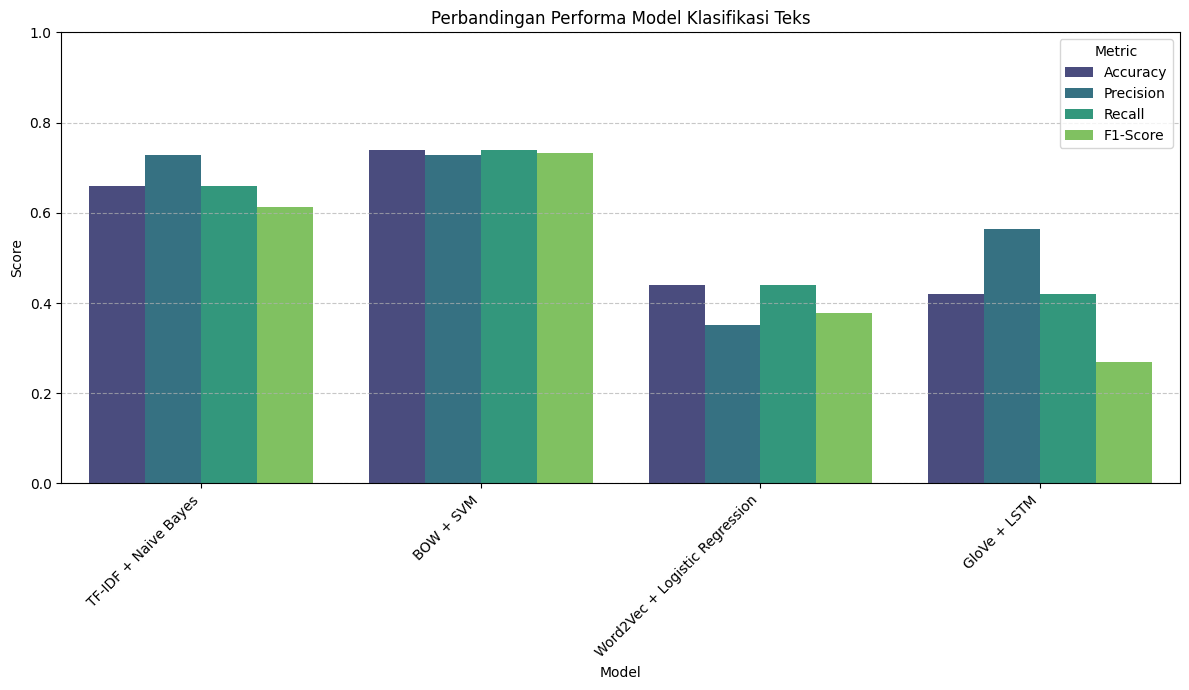

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting
df_results_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_results_melted, palette='viridis')
plt.title('Perbandingan Performa Model Klasifikasi Teks')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are usually between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate model names for better readability
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Ringkasan Temuan

Berdasarkan perbandingan performa model yang telah dievaluasi:

### Performa Model:

| Model                          | Accuracy | Precision | Recall | F1-Score |
|:-------------------------------|:---------|:----------|:-------|:---------|
| TF-IDF + Naive Bayes           | 0.66     | 0.7286    | 0.66   | 0.6124   |
| BOW + SVM                      | 0.74     | 0.7291    | 0.74   | 0.7327   |
| Word2Vec + Logistic Regression | 0.44     | 0.3515    | 0.44   | 0.3778   |
| GloVe + LSTM                   | 0.42     | 0.5633    | 0.42   | 0.2700   |

### Analisis:

1.  **Model Terbaik**: **Bag-of-Words (BOW) dengan Support Vector Machine (SVM)** menunjukkan performa terbaik di antara semua model yang diuji, dengan Akurasi **0.74**, Presisi **0.7291**, Recall **0.74**, dan F1-Score **0.7327**.
2.  **Performa Kompetitif**: **TF-IDF dengan Naive Bayes** juga menunjukkan performa yang layak, terutama pada Presisi, namun Akurasi dan F1-Score sedikit di bawah BOW + SVM.
3.  **Performa Kurang Optimal**: Model yang menggunakan representasi embedding (Word2Vec dan GloVe) dengan Logistic Regression atau LSTM secara signifikan berkinerja lebih rendah dibandingkan dengan model berbasis frekuensi kata (TF-IDF dan BOW) pada dataset ini. Ini mungkin disebabkan oleh ukuran dataset yang kecil atau hyperparameter yang belum dioptimalkan untuk model-model berbasis neural network. Word2Vec + Logistic Regression memiliki F1-Score **0.3778**, dan GloVe + LSTM memiliki F1-Score terendah **0.2700**.

### Kesimpulan:

Untuk tugas klasifikasi teks pada dataset ini, **kombinasi ekstraksi fitur Bag-of-Words (BOW) dengan algoritma klasifikasi Support Vector Machine (SVM) adalah yang paling efektif** berdasarkan metrik evaluasi yang digunakan. Hal ini menunjukkan bahwa representasi fitur yang lebih sederhana dan model machine learning tradisional mungkin lebih cocok atau memerlukan lebih sedikit data/penyesuaian untuk mencapai performa yang baik pada dataset spesifik ini dibandingkan dengan pendekatan berbasis embedding yang lebih kompleks.